In [22]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- Config ---
csv_path = Path("/Users/connerbaucom/Desktop/Pieri/CTG/dim_red_comp/SeamStress/evaluate_feature_output/benzene_s0/feature_metrics.csv") 
out_dir = Path("plots")
out_dir.mkdir(exist_ok=True)

# Optional: customize labels/colors
STRATEGY_LABELS = {
    "cartesian": "Cartesian",
    "inv_dist": "Inverse Distance",
    "inv_eig": "Inverse Eigen",
    "soap": "SOAP",
    "mbtr": "MBTR",
}

STRATEGY_COLORS = {
    "cartesian": "#1f77b4",
    "inv_dist": "#ff7f0e",
    "inv_eig": "#2ca02c",
    "soap": "#d62728",
    "mbtr": "#9467bd",
}

# --- Load data ---
df = pd.read_csv(csv_path)

# Sort strategies for consistent ordering
df = df.sort_values("strategy")

metrics_list = df.to_dict(orient="records")
strategies = df["strategy"].tolist()


# knn
def plot_knn(metrics_list, out_path):
    k_tags = ["k5pct", "k10pct", "k20pct"]
    k_labels = ["k = 5%", "k = 10%", "k = 20%"]

    x = np.arange(len(k_tags))
    width = 0.15

    fig, ax = plt.subplots(figsize=(7,4))

    for i, m in enumerate(metrics_list):
        vals = [m[f"knn_overlap_{t}"] for t in k_tags]
        offset = (i - len(metrics_list)/2) * width + width/2

        ax.bar(
            x + offset,
            vals,
            width,
            label=STRATEGY_LABELS[m["strategy"]],
            color=STRATEGY_COLORS[m["strategy"]],
            alpha=0.85
        )

    ax.set_xticks(x)
    ax.set_xticklabels(k_labels)
    ax.set_ylim(0, 1)
    ax.set_ylabel("k-NN overlap")
    ax.set_title("Local Neighborhood preservation of Features")
    ax.legend(fontsize=9)
    ax.axhline(1.0, color="k", lw=0.8, ls="--")

    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.show()


#correlations
def plot_correlation(df, out_path):
    x = np.arange(len(df))
    width = 0.35

    fig, ax = plt.subplots(figsize=(7,4))

    ax.bar(
        x - width/2,
        df["spearman"],
        width,
        label="Spearman",
        color="#4c72b0"
    )

 

    ax.set_xticks(x)
    ax.set_xticklabels([STRATEGY_LABELS[s] for s in df["strategy"]], rotation=20)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Correlation")
    ax.set_title("Spearman Correlation of Features")
    #ax.legend()

    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.show()


#error 
def plot_error(df, out_path):
    x = np.arange(len(df))
    width = 0.35

    fig, ax = plt.subplots(figsize=(7,4))

    ax.bar(
        x - width/2,
        df["mse"],
        width,
        label="MSE",
        color="#55a868"
    )

    ax.bar(
        x + width/2,
        df["frobenius_rel"],
        width,
        label="Frobenius (rel)",
        color="#c44e52"
    )

    ax.set_xticks(x)
    ax.set_xticklabels([STRATEGY_LABELS[s] for s in df["strategy"]], rotation=20)
    ax.set_ylabel("Error")
    ax.set_title("Error of Features")
    ax.legend()

    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.show()





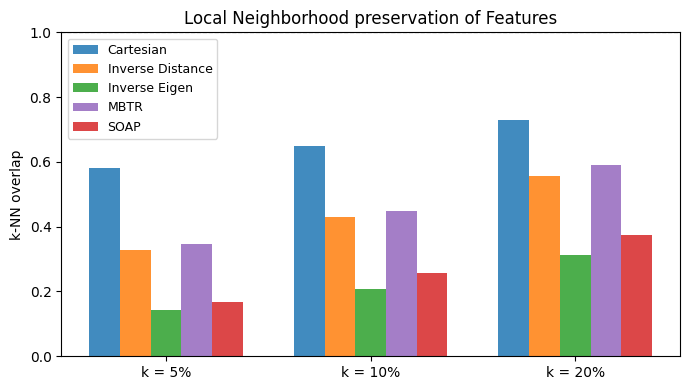

In [23]:

#run knn
plot_knn(metrics_list, out_dir / "knn.png")


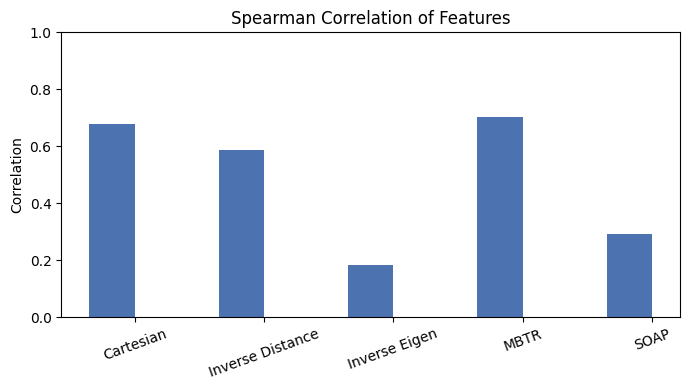

In [24]:
#run correlation
plot_correlation(df, out_dir / "correlation.png")


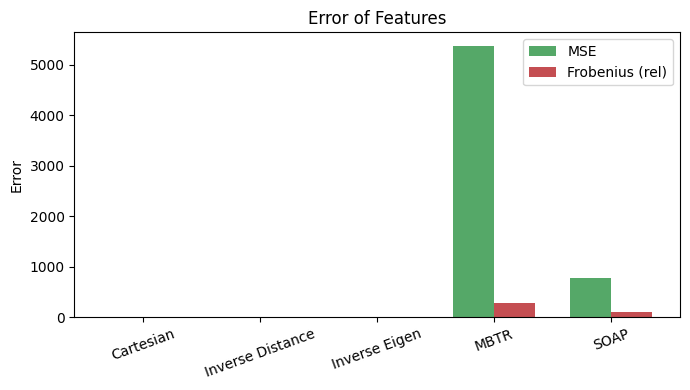

In [19]:
#run error 
plot_error(df, out_dir / "error.png")